In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/robiulhasanjisan/bengali-customer-feedback-dataset/reviewqualitylabels.csv


##  LOAD DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix




file_path = "/kaggle/input/datasets/robiulhasanjisan/bengali-customer-feedback-dataset/reviewqualitylabels.csv"
df = pd.read_csv(file_path)

# Preview
df.head(5)


,review_text,rating,date,review_length,product_quality_label,delivery_quality_label,product_quality_label_num,delivery_quality_label_num
0,"আদৌও কি আমার রিফান্ড পাবো, প্রিয় ই- ভালি?????...",2,19 Nov 2026,60,bad,bad,0,0
1,আপনাদের প্রায়োরিটি স্টোর T10 এর আগের পণ্য গুল...,3,07 Sep 2024,132,bad,bad,0,0
2,Order করেছি কিন্তু এখনো নোটিফিকেশন এর মাধ্যমে ...,1,08 Jun 2022,69,bad,bad,0,0
3,পেমেন্ট করতে চাইলে নিচের মেসেজ টা শো করছেআমার ...,1,06 Nov 2023,70,bad,bad,0,0
4,msung M01s এটা ৭ দিনের গ্যারান্টেড ডেলিভারির ক...,2,25 Aug 2026,286,bad,bad,0,0


##  BASIC DATA EXPLORATION

In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nLabel distribution (Product Quality):\n", df['product_quality_label'].value_counts())
print("\nLabel distribution (Delivery Quality):\n", df['delivery_quality_label'].value_counts())


Dataset shape: (15696, 8)

Columns: ['review_text', 'rating', 'date', 'review_length', 'product_quality_label', 'delivery_quality_label', 'product_quality_label_num', 'delivery_quality_label_num']

Missing values:
 review_text                   0
rating                        0
date                          0
review_length                 0
product_quality_label         0
delivery_quality_label        0
product_quality_label_num     0
delivery_quality_label_num    0
dtype: int64

Label distribution (Product Quality):
 product_quality_label
good    10254
bad      5442
Name: count, dtype: int64

Label distribution (Delivery Quality):
 delivery_quality_label
good    7923
bad     7773
Name: count, dtype: int64


##  DATA CLEANING

In [4]:

def clean_text(text):
    text = str(text)
    # Remove unwanted characters (punctuation, extra spaces)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_review'] = df['review_text'].apply(clean_text)

##  EXPLORATORY DATA ANALYSIS

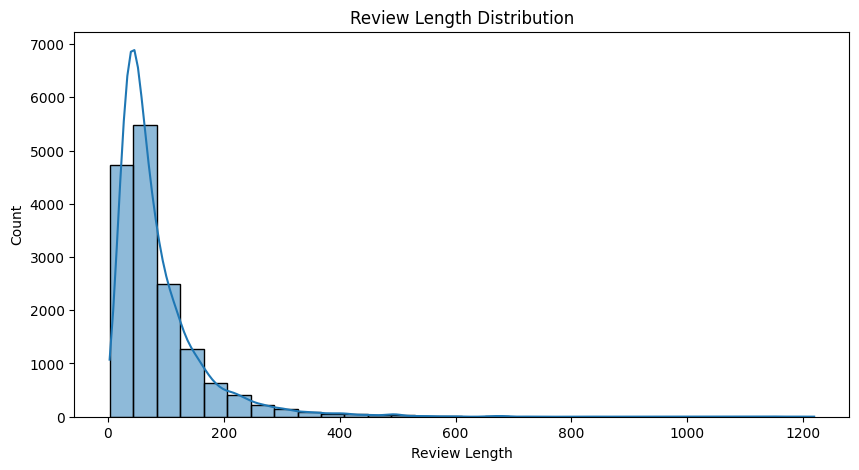

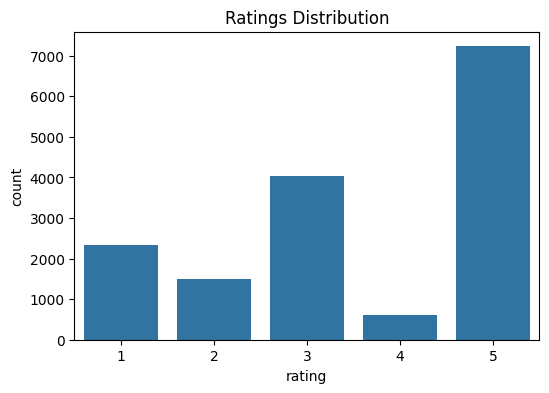

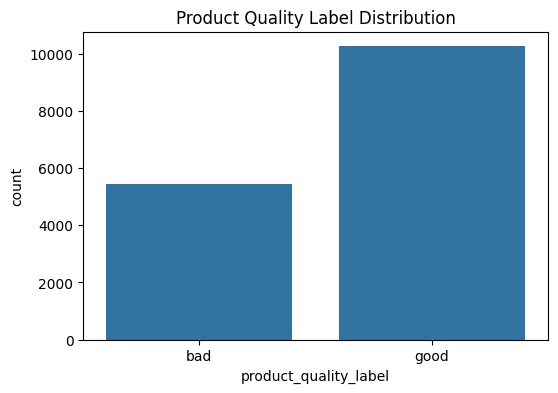

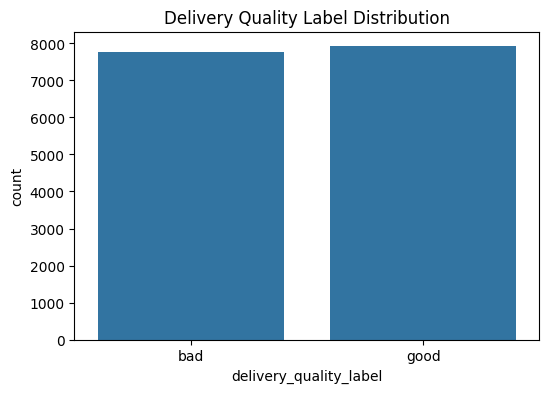

In [5]:

# Review length distribution
plt.figure(figsize=(10,5))
sns.histplot(df['review_length'], bins=30, kde=True)
plt.title('Review Length Distribution')
plt.xlabel('Review Length')
plt.ylabel('Count')
plt.show()

# Ratings distribution
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)
plt.title('Ratings Distribution')
plt.show()

# Product Quality Label Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='product_quality_label', data=df)
plt.title('Product Quality Label Distribution')
plt.show()

## Delivery Quality Label Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='delivery_quality_label', data=df)
plt.title('Delivery Quality Label Distribution')
plt.show()


##  TEXT VECTORIZATION

In [6]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_review'])


##  TRAIN-TEST SPLIT

In [7]:
# Product Quality
y_product = df['product_quality_label_num']
X_train_prod, X_test_prod, y_train_prod, y_test_prod = train_test_split(
    X, y_product, test_size=0.2, random_state=42, stratify=y_product
)

# Delivery Quality
y_delivery = df['delivery_quality_label_num']
X_train_del, X_test_del, y_train_del, y_test_del = train_test_split(
    X, y_delivery, test_size=0.2, random_state=42, stratify=y_delivery
)


##  MODEL TRAINING: LOGISTIC REGRESSION

In [8]:
# Product Quality Model
model_prod = LogisticRegression(max_iter=500)
model_prod.fit(X_train_prod, y_train_prod)
y_pred_prod = model_prod.predict(X_test_prod)

# Delivery Quality Model
model_del = LogisticRegression(max_iter=500)
model_del.fit(X_train_del, y_train_del)
y_pred_del = model_del.predict(X_test_del)

## MODEL EVALUATION

=== Product Quality Classification Report ===
              precision    recall  f1-score   support

           0       0.76      0.60      0.67      1089
           1       0.81      0.90      0.85      2051

    accuracy                           0.80      3140
   macro avg       0.78      0.75      0.76      3140
weighted avg       0.79      0.80      0.79      3140

=== Delivery Quality Classification Report ===
              precision    recall  f1-score   support

           0       0.72      0.70      0.71      1555
           1       0.71      0.73      0.72      1585

    accuracy                           0.72      3140
   macro avg       0.72      0.72      0.72      3140
weighted avg       0.72      0.72      0.72      3140



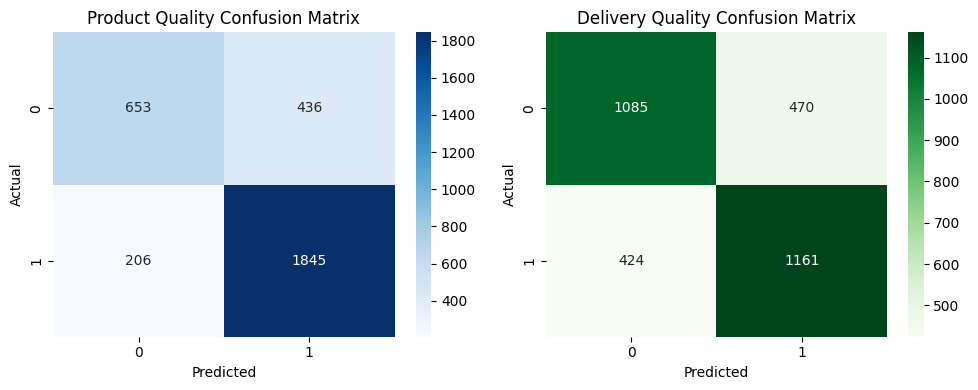

In [9]:
print("=== Product Quality Classification Report ===")
print(classification_report(y_test_prod, y_pred_prod))

print("=== Delivery Quality Classification Report ===")
print(classification_report(y_test_del, y_pred_del))

# Confusion matrices
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test_prod, y_pred_prod), annot=True, fmt='d', cmap='Blues')
plt.title('Product Quality Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test_del, y_pred_del), annot=True, fmt='d', cmap='Greens')
plt.title('Delivery Quality Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()


